In [2]:
import pandas as pd
import matplotlib.pyplot as plt
import xarray as xr
import netCDF4 as nc

In [3]:
fn = '/Users/jadawhite/Documents/GitHub/ISAT 420/ISAT-Semester-Project/Data/Maria_precp.nc'
ds = nc.Dataset(fn)

In [4]:
print (ds)

<class 'netCDF4.Dataset'>
root group (NETCDF4 data model, file format HDF5):
    GRIB_centre: ecmf
    GRIB_centreDescription: European Centre for Medium-Range Weather Forecasts
    GRIB_subCentre: 0
    Conventions: CF-1.7
    institution: European Centre for Medium-Range Weather Forecasts
    history: 2026-04-22T20:11 GRIB to CDM+CF via cfgrib-0.9.15.1/ecCodes-2.42.0 with {"source": "tmpul1w2hyd/data.grib", "filter_by_keys": {"stream": ["oper"], "stepType": ["accum"]}, "encode_cf": ["parameter", "time", "geography", "vertical"]}
    dimensions(sizes): valid_time(120), latitude(31), longitude(81)
    variables(dimensions): int64 number(), int64 valid_time(valid_time), float64 latitude(latitude), float64 longitude(longitude), <class 'str'> expver(valid_time), float32 tp(valid_time, latitude, longitude)
    groups: 


In [5]:
df = xr.open_dataset(fn)
df

<xarray.Dataset> Size: 1MB
Dimensions:     (valid_time: 120, latitude: 31, longitude: 81)
Coordinates:
  * valid_time  (valid_time) datetime64[ns] 960B 2017-09-18 ... 2017-09-22T23...
  * latitude    (latitude) float64 248B 20.0 19.75 19.5 ... 13.0 12.75 12.5
  * longitude   (longitude) float64 648B -70.0 -69.75 -69.5 ... -50.25 -50.0
    number      int64 8B ...
    expver      (valid_time) <U4 2kB ...
Data variables:
    tp          (valid_time, latitude, longitude) float32 1MB ...
Attributes:
    GRIB_centre:             ecmf
    GRIB_centreDescription:  European Centre for Medium-Range Weather Forecasts
    GRIB_subCentre:          0
    Conventions:             CF-1.7
    institution:             European Centre for Medium-Range Weather Forecasts
    history:                 2026-04-22T20:11 GRIB to CDM+CF via cfgrib-0.9.1...

In [6]:
df['tp'].attrs

{'GRIB_paramId': np.int64(228),
 'GRIB_dataType': 'fc',
 'GRIB_numberOfPoints': np.int64(2511),
 'GRIB_typeOfLevel': 'surface',
 'GRIB_stepUnits': np.int64(1),
 'GRIB_stepType': 'accum',
 'GRIB_gridType': 'regular_ll',
 'GRIB_uvRelativeToGrid': np.int64(0),
 'GRIB_NV': np.int64(0),
 'GRIB_Nx': np.int64(81),
 'GRIB_Ny': np.int64(31),
 'GRIB_cfName': 'unknown',
 'GRIB_cfVarName': 'tp',
 'GRIB_gridDefinitionDescription': 'Latitude/Longitude Grid',
 'GRIB_iDirectionIncrementInDegrees': np.float64(0.25),
 'GRIB_iScansNegatively': np.int64(0),
 'GRIB_jDirectionIncrementInDegrees': np.float64(0.25),
 'GRIB_jPointsAreConsecutive': np.int64(0),
 'GRIB_jScansPositively': np.int64(0),
 'GRIB_latitudeOfFirstGridPointInDegrees': np.float64(20.0),
 'GRIB_latitudeOfLastGridPointInDegrees': np.float64(12.5),
 'GRIB_longitudeOfFirstGridPointInDegrees': np.float64(-70.0),
 'GRIB_longitudeOfLastGridPointInDegrees': np.float64(-50.0),
 'GRIB_missingValue': np.float64(3.4028234663852886e+38),
 'GRIB_name':

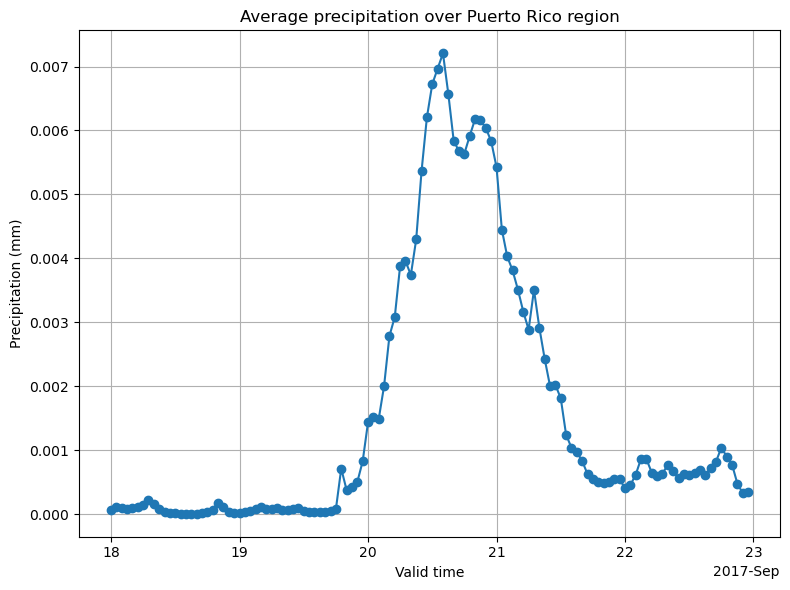

In [7]:
pr_region = df['tp'].sel(latitude=slice(19.5, 17.0), longitude=slice(-68.0, -65.0))
pr_ts = pr_region.mean(dim=['latitude', 'longitude'])

plt.figure(figsize=(8, 6))
pr_ts.plot(marker='o')
plt.title('Average precipitation over Puerto Rico region')
plt.xlabel('Valid time')
plt.ylabel('Precipitation (mm)')
plt.grid(True)
plt.tight_layout()

/opt/anaconda3/envs/condaenvs26/lib/python3.14/site-packages/shapely/predicates.py:878: RuntimeWarning: invalid value encountered in intersects
  return lib.intersects(a, b, **kwargs)
/opt/anaconda3/envs/condaenvs26/lib/python3.14/site-packages/shapely/predicates.py:878: RuntimeWarning: invalid value encountered in intersects
  return lib.intersects(a, b, **kwargs)
/opt/anaconda3/envs/condaenvs26/lib/python3.14/site-packages/shapely/constructive.py:246: RuntimeWarning: invalid value encountered in buffer
  return lib.buffer(
/opt/anaconda3/envs/condaenvs26/lib/python3.14/site-packages/shapely/predicates.py:878: RuntimeWarning: invalid value encountered in intersects
  return lib.intersects(a, b, **kwargs)
/opt/anaconda3/envs/condaenvs26/lib/python3.14/site-packages/shapely/constructive.py:246: RuntimeWarning: invalid value encountered in buffer
  return lib.buffer(
/opt/anaconda3/envs/condaenvs26/lib/python3.14/site-packages/shapely/constructive.py:246: RuntimeWarning: invalid value en

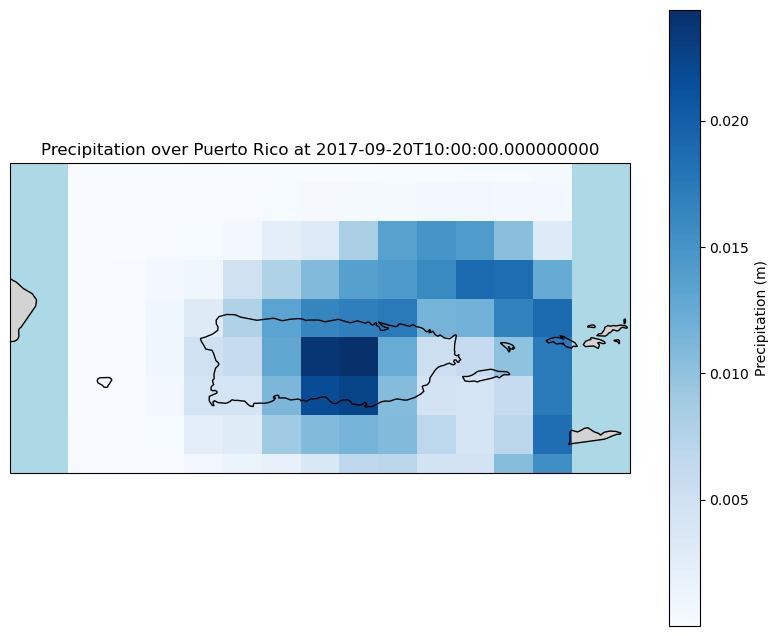

In [8]:
import cartopy.crs as ccrs
import cartopy.feature as cfeature

# Select a specific time step for plotting (e.g., the first one, or you can loop for animation)
time_step = '2017-09-20T10:15:00'  # 03:00 UTC Sep 20 (11pm AST Sep 19)
precip_data = pr_region.sel(method='nearest', valid_time=time_step)

# Create a figure with a map projection
fig, ax = plt.subplots(figsize=(10, 8), subplot_kw={'projection': ccrs.PlateCarree()})

# Plot the precipitation data
precip_data.plot(ax=ax, cmap='Blues', add_colorbar=True, cbar_kwargs={'label': 'Precipitation (m)'})

# Add geographical features
ax.add_feature(cfeature.COASTLINE)
ax.add_feature(cfeature.BORDERS)
ax.add_feature(cfeature.LAND, facecolor='lightgray')
ax.add_feature(cfeature.OCEAN, facecolor='lightblue')

# Set the extent to focus on Puerto Rico
ax.set_extent([-68.5, -64.5, 17.5, 19.5], crs=ccrs.PlateCarree())

# Add title
ax.set_title(f'Precipitation over Puerto Rico at {precip_data.valid_time.values}')

plt.show()

In [9]:
fn_wind = '/Users/jadawhite/Documents/GitHub/ISAT 420/ISAT-Semester-Project/Data/maria_wind.nc'
df_wind = xr.open_dataset(fn_wind)

In [10]:
print (df_wind)

<xarray.Dataset> Size: 10MB
Dimensions:     (valid_time: 120, latitude: 131, longitude: 81)
Coordinates:
  * valid_time  (valid_time) datetime64[ns] 960B 2017-09-18 ... 2017-09-22T23...
  * latitude    (latitude) float64 1kB 20.0 19.75 19.5 ... -12.0 -12.25 -12.5
  * longitude   (longitude) float64 648B -70.0 -69.75 -69.5 ... -50.25 -50.0
    number      int64 8B ...
    expver      (valid_time) <U4 2kB ...
Data variables:
    u10         (valid_time, latitude, longitude) float32 5MB ...
    v10         (valid_time, latitude, longitude) float32 5MB ...
Attributes:
    GRIB_centre:             ecmf
    GRIB_centreDescription:  European Centre for Medium-Range Weather Forecasts
    GRIB_subCentre:          0
    Conventions:             CF-1.7
    institution:             European Centre for Medium-Range Weather Forecasts
    history:                 2026-04-27T20:37 GRIB to CDM+CF via cfgrib-0.9.1...


/opt/anaconda3/envs/condaenvs26/lib/python3.14/site-packages/shapely/constructive.py:246: RuntimeWarning: invalid value encountered in buffer
  return lib.buffer(
/opt/anaconda3/envs/condaenvs26/lib/python3.14/site-packages/shapely/predicates.py:878: RuntimeWarning: invalid value encountered in intersects
  return lib.intersects(a, b, **kwargs)
/opt/anaconda3/envs/condaenvs26/lib/python3.14/site-packages/shapely/constructive.py:246: RuntimeWarning: invalid value encountered in buffer
  return lib.buffer(
/opt/anaconda3/envs/condaenvs26/lib/python3.14/site-packages/shapely/predicates.py:878: RuntimeWarning: invalid value encountered in intersects
  return lib.intersects(a, b, **kwargs)
/opt/anaconda3/envs/condaenvs26/lib/python3.14/site-packages/shapely/constructive.py:246: RuntimeWarning: invalid value encountered in buffer
  return lib.buffer(
/opt/anaconda3/envs/condaenvs26/lib/python3.14/site-packages/shapely/predicates.py:878: RuntimeWarning: invalid value encountered in intersects

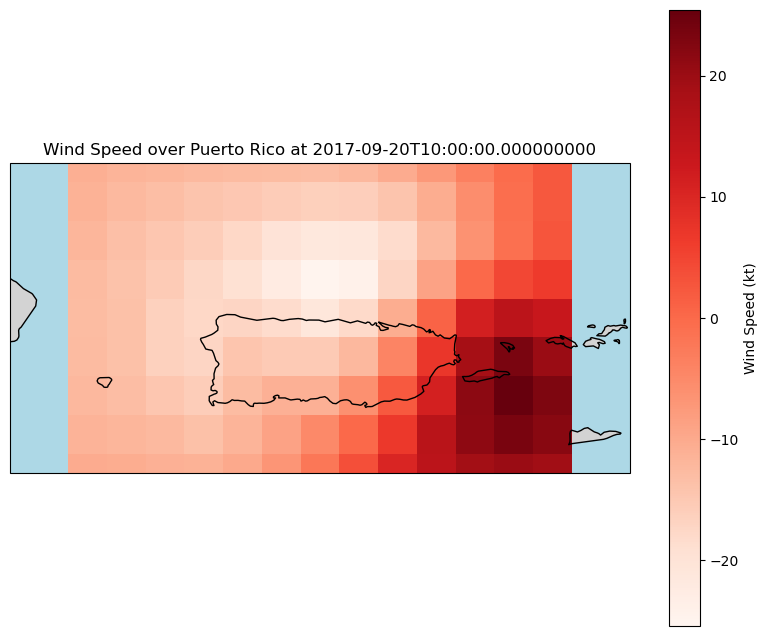

In [11]:


# Select the wind variable (adjust variable name if needed)
wind_var = df_wind['v10']  # Change 'wind' to actual variable name in your dataset

# Select the same region as precipitation
wind_region = wind_var.sel(latitude=slice(19.5, 17.0), longitude=slice(-68.0, -65.0))

# Select the same time step
wind_data_new = wind_region.sel(method='nearest', valid_time=time_step)

# Create a figure with a map projection
fig, ax = plt.subplots(figsize=(10, 8), subplot_kw={'projection': ccrs.PlateCarree()})

# Plot the wind data
wind_data_new.plot(ax=ax, cmap='Reds', add_colorbar=True, cbar_kwargs={'label': 'Wind Speed (kt)'})

# Add geographical features
ax.add_feature(cfeature.COASTLINE)
ax.add_feature(cfeature.BORDERS)
ax.add_feature(cfeature.LAND, facecolor='lightgray')
ax.add_feature(cfeature.OCEAN, facecolor='lightblue')

# Set the extent to focus on Puerto Rico
ax.set_extent([-68.5, -64.5, 17.5, 19.5], crs=ccrs.PlateCarree())

# Add title
ax.set_title(f'Wind Speed over Puerto Rico at {wind_data_new.valid_time.values}')

plt.show()

/opt/anaconda3/envs/condaenvs26/lib/python3.14/site-packages/shapely/constructive.py:246: RuntimeWarning: invalid value encountered in buffer
  return lib.buffer(
/opt/anaconda3/envs/condaenvs26/lib/python3.14/site-packages/shapely/predicates.py:878: RuntimeWarning: invalid value encountered in intersects
  return lib.intersects(a, b, **kwargs)
/opt/anaconda3/envs/condaenvs26/lib/python3.14/site-packages/shapely/constructive.py:246: RuntimeWarning: invalid value encountered in buffer
  return lib.buffer(
/opt/anaconda3/envs/condaenvs26/lib/python3.14/site-packages/shapely/predicates.py:878: RuntimeWarning: invalid value encountered in intersects
  return lib.intersects(a, b, **kwargs)
/opt/anaconda3/envs/condaenvs26/lib/python3.14/site-packages/shapely/constructive.py:246: RuntimeWarning: invalid value encountered in buffer
  return lib.buffer(
/opt/anaconda3/envs/condaenvs26/lib/python3.14/site-packages/shapely/predicates.py:878: RuntimeWarning: invalid value encountered in intersects

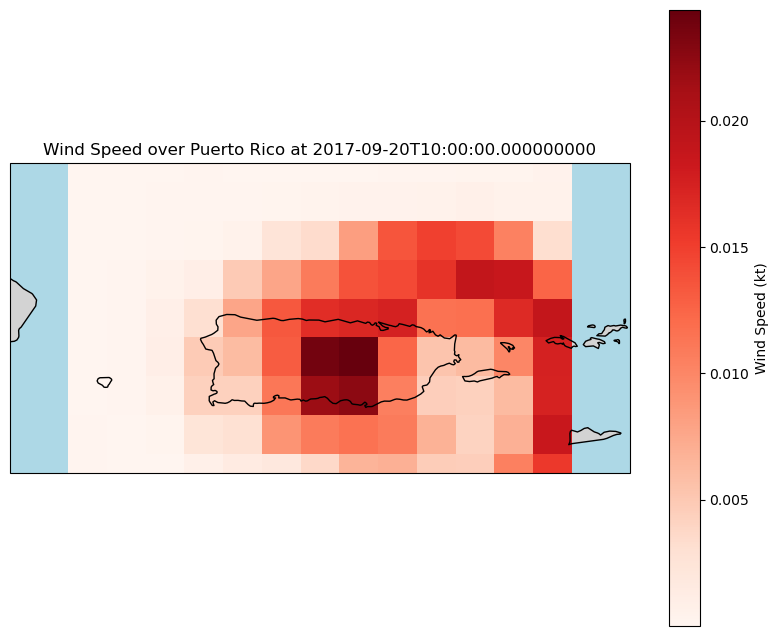

In [12]:
import cartopy.crs as ccrs
import cartopy.feature as cfeature

# Select a specific time step for plotting (e.g., the first one, or you can loop for animation)
time_step = '2017-09-20T10:15:00'  # 03:00 UTC Sep 20 (11pm AST Sep 19)
wind_data = pr_region.sel(method='nearest', valid_time=time_step)

# Create a figure with a map projection
fig, ax = plt.subplots(figsize=(10, 8), subplot_kw={'projection': ccrs.PlateCarree()})

# Plot the precipitation data
wind_data.plot(ax=ax, cmap='Reds', add_colorbar=True, cbar_kwargs={'label': 'Wind Speed (kt)'})

# Add geographical features
ax.add_feature(cfeature.COASTLINE)
ax.add_feature(cfeature.BORDERS)
ax.add_feature(cfeature.LAND, facecolor='lightgray')
ax.add_feature(cfeature.OCEAN, facecolor='lightblue')

# Set the extent to focus on Puerto Rico
ax.set_extent([-68.5, -64.5, 17.5, 19.5], crs=ccrs.PlateCarree())

# Add title
ax.set_title(f'Wind Speed over Puerto Rico at {wind_data.valid_time.values}')

plt.show()

/opt/anaconda3/envs/condaenvs26/lib/python3.14/site-packages/shapely/constructive.py:246: RuntimeWarning: invalid value encountered in buffer
  return lib.buffer(
/opt/anaconda3/envs/condaenvs26/lib/python3.14/site-packages/shapely/predicates.py:878: RuntimeWarning: invalid value encountered in intersects
  return lib.intersects(a, b, **kwargs)
/opt/anaconda3/envs/condaenvs26/lib/python3.14/site-packages/shapely/constructive.py:246: RuntimeWarning: invalid value encountered in buffer
  return lib.buffer(
/opt/anaconda3/envs/condaenvs26/lib/python3.14/site-packages/shapely/predicates.py:878: RuntimeWarning: invalid value encountered in intersects
  return lib.intersects(a, b, **kwargs)
/opt/anaconda3/envs/condaenvs26/lib/python3.14/site-packages/shapely/constructive.py:246: RuntimeWarning: invalid value encountered in buffer
  return lib.buffer(
/opt/anaconda3/envs/condaenvs26/lib/python3.14/site-packages/shapely/predicates.py:878: RuntimeWarning: invalid value encountered in intersects

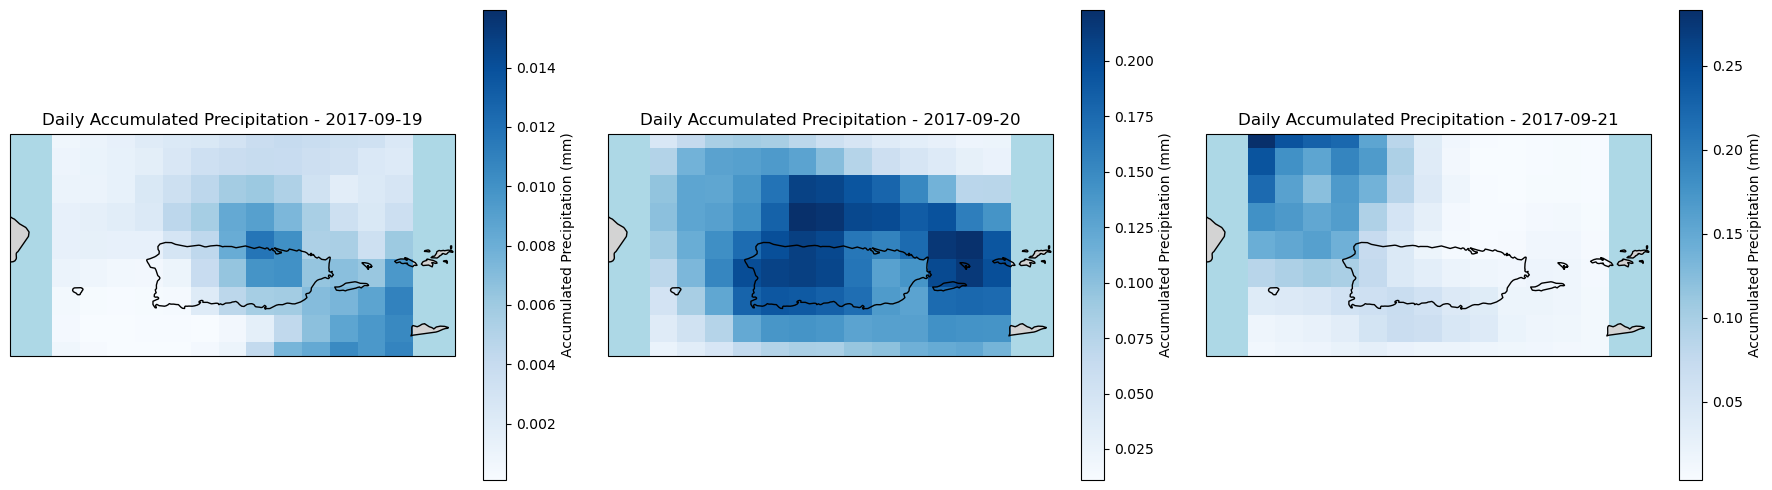

In [13]:
# Calculate daily accumulated precipitation
daily_precip = pr_region.resample(valid_time='1D').sum()

# Create a figure with 3 subplots for the 3 days
fig, axes = plt.subplots(1, 3, figsize=(18, 5), subplot_kw={'projection': ccrs.PlateCarree()})

# Define the three time periods (adjust dates based on your landfall date)
time_periods = [
    '2017-09-19',  # 1 day before landfall
    '2017-09-20',  # Landfall day
    '2017-09-21'   # 1 day after landfall
]

for idx, (ax, date) in enumerate(zip(axes, time_periods)):
    # Select daily precipitation for each date
    daily_data = daily_precip.sel(valid_time=date, method='nearest')
    
    # Plot the precipitation data
    daily_data.plot(ax=ax, cmap='Blues', add_colorbar=True, cbar_kwargs={'label': 'Accumulated Precipitation (mm)'})
    
    # Add geographical features
    ax.add_feature(cfeature.COASTLINE)
    ax.add_feature(cfeature.BORDERS)
    ax.add_feature(cfeature.LAND, facecolor='lightgray')
    ax.add_feature(cfeature.OCEAN, facecolor='lightblue')
    
    # Set the extent to focus on Puerto Rico
    ax.set_extent([-68.5, -64.5, 17.5, 19.5], crs=ccrs.PlateCarree())
    
    # Add title
    ax.set_title(f'Daily Accumulated Precipitation - {date}')

plt.tight_layout()
plt.show()